In [1]:
%config InlineBackend.figure_formats = ['svg']
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('_data/churn-repair_*.csv')]
data = pd.concat(frames, ignore_index=True)
SYS = "Vault"

def classify(r):
    if r['fragment_k'] == 1:
        return "Swarm"
    else:
        cache = int(r['cache_sec']) // 3600
        return f"{SYS}$_{{{cache}}}$"

data['Protocol'] = data.apply(classify, axis=1)
data = data[data['churn_rate'] >= 1.]
data[data['churn_rate'] == 4.][:10]

,churn_rate,node_count,duration,faulty_rate,object_count,chunk_n,chunk_k,fragment_n,fragment_k,cache_sec,targeted_count,data_lost,targeted,repair,alive_count,Protocol
120,4.0,100000,315360000,0,1,100,100,3,1,4294967295,0,0,0,119.980000,3,Swarm
121,4.0,100000,315360000,0,1,10,8,80,32,43200,0,0,0,2761.085938,80,Vault$_{12}$
122,4.0,100000,315360000,0,1,10,8,80,32,43200,0,0,0,2749.609375,80,Vault$_{12}$
124,4.0,100000,315360000,0,1,10,8,80,32,0,0,0,0,4323.875000,80,Vault$_{0}$
127,4.0,100000,315360000,0,1,10,8,80,32,43200,0,0,0,2709.062500,80,Vault$_{12}$
132,4.0,100000,315360000,0,1,10,8,80,32,86400,0,0,0,1763.187500,80,Vault$_{24}$
133,4.0,100000,315360000,0,1,10,8,80,32,21600,0,0,0,3426.476562,80,Vault$_{6}$
134,4.0,100000,315360000,0,1,10,8,80,32,86400,0,0,0,1771.882812,80,Vault$_{24}$
140,4.0,100000,315360000,0,1,100,100,3,1,4294967295,0,0,0,119.800000,3,Swarm
142,4.0,100000,315360000,0,1,10,8,80,32,43200,0,0,0,2739.785156,80,Vault$_{12}$


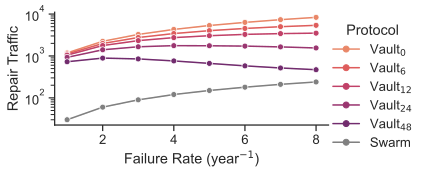

In [2]:
palette = sns.color_palette('flare', n_colors=5)
sns.relplot(data=data, 
    kind="line",
    x="churn_rate", y="repair", hue="Protocol", 
    hue_order=[*[f"{SYS}$_{{{n}}}$" for n in (0, 6, 12, 24, 48)], "Swarm"],
    marker="o", palette=[*palette, 'gray'],
    height=2.56, aspect=2.) \
.set_xlabels("Failure Rate (year$^{-1}$)") \
.set_ylabels("Repair Traffic") \
.set(yscale="log") \
.savefig("churn-repair.pdf")